Batch GD 在第 275 次迭代收敛！
Batch GD 找到的最优 theta: [  0.50325781  -2.33680098  -6.3166952    6.81229897  -1.06338282
   6.67468593   3.41178784  -0.45573762 -12.94593211  15.73289907]
最终的 Cost (误差): 8333.214221090693


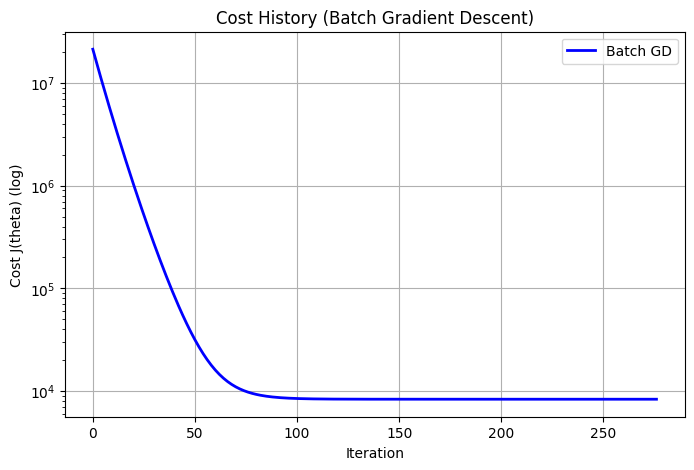

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#————————————————————————基础函数与全批量梯度下降 (Batch GD)——————————————————————
# --- 1. 载入数据 ---
X = np.loadtxt("../p2_fittingdata_x.txt")  
y = np.loadtxt("../p2_fittingdatap2_y.txt")

# --- 2. 基础函数定义 ---
def compute_cost(X, y, theta):
    return np.sum((np.dot(X, theta) - y) ** 2)

def compute_gradient(X, y, theta):
    return 2 * X.T.dot(X.dot(theta) - y)

def compute_sgd_gradient(x_i, y_i, theta):
    return 2 * (np.dot(x_i, theta) - y_i) * x_i

# --- 3. Batch GD 实现 ---
def batch_gd(X, y, init_theta, step_size, epsilon, max_iter=2000):
    theta = init_theta.copy()
    cost_history = []
    
    for i in range(max_iter):
        current_cost = compute_cost(X, y, theta)
        cost_history.append(current_cost)
        
        grad = compute_gradient(X, y, theta)
        next_theta = theta - step_size * grad
        next_cost = compute_cost(X, y, next_theta)
        
        if abs(next_cost - current_cost) < epsilon:
            theta = next_theta
            cost_history.append(next_cost)
            print(f"Batch GD 在第 {i} 次迭代收敛！")
            break
            
        theta = next_theta
    return theta, cost_history

# --- 4. 运行 Batch GD ---
num_features = X.shape[1]
init_theta = np.zeros(num_features)
step_size_batch, epsilon_batch, max_iter_batch = 0.000001, 1e-6, 1000

opt_theta_batch, cost_history_batch = batch_gd(X, y, init_theta, step_size_batch, epsilon_batch, max_iter_batch)
print("Batch GD 找到的最优 theta:", opt_theta_batch)
print("最终的 Cost (误差):", cost_history_batch[-1])

# 画图
plt.figure(figsize=(8, 5))
plt.plot(cost_history_batch, color='blue', linewidth=2, label='Batch GD')
plt.yscale('log') 
plt.title("Cost History (Batch Gradient Descent)")
plt.xlabel("Iteration")
plt.ylabel("Cost J(theta) (log)")
plt.grid(True); plt.legend(); plt.show()


SGD 找到的最优 theta: [  0.54818127  -2.34508764  -6.35249989   6.89447392  -1.07338146
   6.6974685    3.41346457  -0.54220124 -13.10875814  15.68105391]
SGD 最终的 Cost (误差): 10627.357533965898


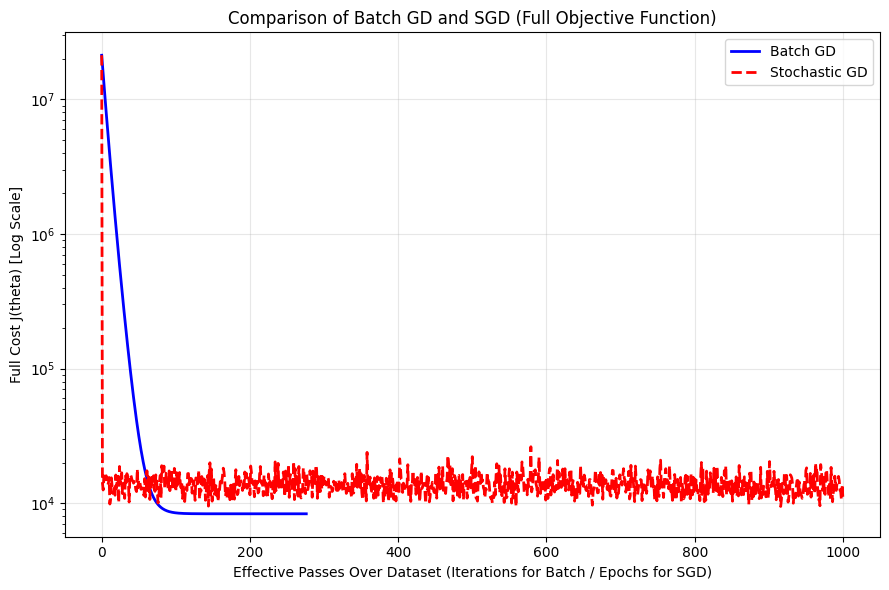

In [5]:
# --- 1. SGD 动态步长函数 ---
def dynamic_step_size(t, tau0=5000000, kappa=0.6):
    return (tau0 + t) ** (-kappa)

# --- 2. SGD 基础版 ---
def sgd_function(obj, grad, data, init_guess, step_size, epsilon, max_epoch=1000):
    X, y = data
    n_samples = X.shape[0]
    opt_point = init_guess.copy().astype(float)
    current_cost = obj(X, y, opt_point)
    t = 1 
    
    for epoch in range(max_epoch):
        indices = np.random.permutation(n_samples)
        X_shuffled, y_shuffled = X[indices], y[indices]
        
        for i in range(n_samples):
            current_grad = grad(X_shuffled[i], y_shuffled[i], opt_point)
            opt_point = opt_point - step_size(t) * current_grad
            t += 1
            
        next_cost = obj(X, y, opt_point)
        if abs(next_cost - current_cost) < epsilon:
            print(f"SGD (基础版) 收敛于第 {epoch + 1} 个 Epoch")
            break
        current_cost = next_cost

    return opt_point

# --- 3. SGD 进阶版 (返回历史记录，用于绘图对比) ---
def sgd_function_with_history(obj, grad, data, init_guess, step_size_fn, epsilon, max_epoch=1000, grad_clip=None):
    X_local, y_local = data
    n_samples = X_local.shape[0]
    theta = init_guess.copy().astype(float)
    current_cost = obj(X_local, y_local, theta)
    cost_history = [current_cost]
    t = 1 
    
    for epoch in range(max_epoch):
        indices = np.random.permutation(n_samples)
        X_shuffled, y_shuffled = X_local[indices], y_local[indices]
        
        for i in range(n_samples):
            current_grad = grad(X_shuffled[i], y_shuffled[i], theta)
            if grad_clip is not None: 
                current_grad = np.clip(current_grad, -grad_clip, grad_clip)
            theta = theta - step_size_fn(t) * current_grad
            t += 1
            
        next_cost = obj(X_local, y_local, theta)
        cost_history.append(next_cost)
        if abs(next_cost - current_cost) < epsilon:
            break
        current_cost = next_cost

    return theta, cost_history

# --- 4. 运行 SGD 并记录历史 ---
data_tuple = (X, y)
epsilon_sgd, max_epoch_sgd = 1e-6, 1000

np.random.seed(42)  
opt_theta_sgd, cost_history_sgd = sgd_function_with_history(
    obj=compute_cost, grad=compute_sgd_gradient, data=data_tuple, 
    init_guess=init_theta, step_size_fn=dynamic_step_size, 
    epsilon=epsilon_sgd, max_epoch=max_epoch_sgd
)

print("\nSGD 找到的最优 theta:", opt_theta_sgd)
print("SGD 最终的 Cost (误差):", cost_history_sgd[-1])

# --- 5. 画出 SGD 和 Batch GD 的对比曲线 (Q3) ---
plt.figure(figsize=(9, 6))

# 画出 Batch GD 的下降曲线 (蓝色实线)
plt.plot(cost_history_batch, color='blue', linewidth=2, label='Batch GD')

# 画出 SGD 的下降曲线 (红色虚线)，过滤非正值以防对数坐标轴报错
sgd_vals = np.asarray(cost_history_sgd, dtype=float)
sgd_mask = np.isfinite(sgd_vals) & (sgd_vals > 0)
if np.any(sgd_mask):
    plt.plot(np.where(sgd_mask)[0], sgd_vals[sgd_mask], color='red', linewidth=2, linestyle='--', label='Stochastic GD')

plt.yscale('log') 
plt.title("Comparison of Batch GD and SGD (Full Objective Function)")
plt.xlabel("Effective Passes Over Dataset (Iterations for Batch / Epochs for SGD)")
plt.ylabel("Full Cost J(theta) [Log Scale]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#——————————————————————SGD 超参数网格分析 (4x3 多子图绘制)——————————————————————————
# --- 1. 设定超参数组合 ---
tau_levels = [
    (50000000, "tau0=5e7 (Very Large)"),
    (5000000,  "tau0=5e6 (Large)"),
    (500000,   "tau0=5e5 (Suitable)"),
    (50000,    "tau0=5e4 (Small)")
]
kappa_levels = [0.6, 0.7, 0.8]

# --- 2. 批量运行并绘制 4x3 网格图 ---
np.random.seed(42) 
fig, axes = plt.subplots(nrows=len(tau_levels), ncols=len(kappa_levels), 
                         figsize=(18, 16), sharex=True, sharey=True)

Y_MIN_SAFE, Y_MAX_SAFE = 1e-1, 1e8
bgd = np.asarray(cost_history_batch, dtype=float)
bgd_mask = np.isfinite(bgd) & (bgd > 0)

for row, (tau0, tau_label) in enumerate(tau_levels):
    for col, kappa in enumerate(kappa_levels):
        ax = axes[row, col]
        
        # 匿名函数封装动态步长
        step_size_case = lambda t, t0=tau0, k=kappa: (t0 + t) ** (-k)
        
        theta_case, cost_hist_case = sgd_function_with_history(
            obj=compute_cost, grad=compute_sgd_gradient, data=(X, y), 
            init_guess=init_theta, step_size_fn=step_size_case, 
            epsilon=1e-6, max_epoch=1000, grad_clip=1e4
        )
        
        sgd = np.asarray(cost_hist_case, dtype=float)
        sgd_mask = np.isfinite(sgd) & (sgd > 0)

        # 绘制背景 BGD 参照线
        if np.any(bgd_mask):
            ax.plot(np.where(bgd_mask)[0], np.clip(bgd[bgd_mask], Y_MIN_SAFE, Y_MAX_SAFE), 
                    color="blue", linewidth=2.5, alpha=0.7, label="Batch GD")
        
        # 绘制当前参数下的 SGD 曲线
        if np.any(sgd_mask):
            ax.plot(np.where(sgd_mask)[0], np.clip(sgd[sgd_mask], Y_MIN_SAFE, Y_MAX_SAFE), 
                    color="red", linewidth=1.5, linestyle="--", label="SGD")

        # 坐标轴与排版处理
        ax.set_yscale("log")
        ax.set_ylim(Y_MIN_SAFE, Y_MAX_SAFE)
        ax.set_title(f"{tau_label}\nkappa = {kappa}", fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        if row == len(tau_levels) - 1: ax.set_xlabel("Epoch / Iteration", fontsize=10)
        if col == 0: ax.set_ylabel("Cost (log scale)", fontsize=10)
        if row == 0 and col == 0: ax.legend(loc="upper right")

fig.suptitle("Hyperparameter Analysis for SGD vs Batch GD", fontsize=16, y=0.98)
plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.savefig("sgd_hyperparameter_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

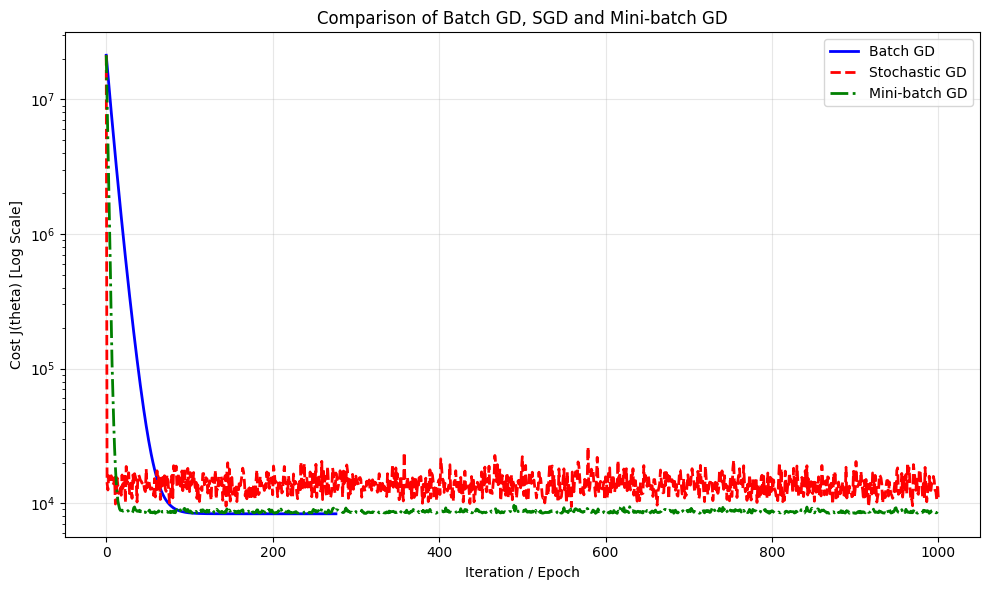

In [ ]:
#———————————————————————小批量梯度下降 (Mini-batch GD) 及综合对比————————————————————
# --- 1. Mini-batch GD 步长与实现 ---
def dynamic_step_size_minibatch(t, tau0=3000000, kappa=0.6):
    return (tau0 + t) ** (-kappa)

def minibatch_gd_function(obj, grad, data, init_guess, step_size, epsilon, n_batch=32, max_epoch=1000):
    X, y = data
    n_samples = X.shape[0]
    n_batch = min(n_batch, n_samples)
    opt_point = init_guess.copy().astype(float)
    current_cost = obj(X, y, opt_point)
    cost_history = [current_cost]
    t = 1 

    for epoch in range(max_epoch):
        indices = np.random.permutation(n_samples)
        X_shuffled, y_shuffled = X[indices], y[indices]

        for start in range(0, n_samples, n_batch):
            end = start + n_batch
            X_batch, y_batch = X_shuffled[start:end], y_shuffled[start:end]
            # 计算 Batch 均值梯度
            current_grad = grad(X_batch, y_batch, opt_point) / X_batch.shape[0]
            opt_point = opt_point - step_size(t) * current_grad
            t += 1

        next_cost = obj(X, y, opt_point)
        cost_history.append(next_cost)
        
        if not np.isfinite(next_cost) or abs(next_cost - current_cost) < epsilon:
            print(f"Mini-batch GD 收敛或停止于第 {epoch + 1} 个 Epoch")
            break
        current_cost = next_cost

    return opt_point, cost_history

# --- 2. 运行 Mini-batch GD ---
np.random.seed(42)
opt_theta_minibatch, cost_history_minibatch = minibatch_gd_function(
    obj=compute_cost, grad=compute_gradient, data=(X, y), 
    init_guess=init_theta, step_size=dynamic_step_size_minibatch, 
    epsilon=1e-6, n_batch=32, max_epoch=1000
)

# --- 3. 画出三者对比图 ---
plt.figure(figsize=(10, 6))

plot_configs = [
    (cost_history_batch, "blue", "-", "Batch GD"),
    (cost_history_sgd, "red", "--", "Stochastic GD"),
    (cost_history_minibatch, "green", "-.", "Mini-batch GD")
]

for hist, color, style, label in plot_configs:
    vals = np.asarray(hist, dtype=float)
    mask = np.isfinite(vals) & (vals > 0)
    if np.any(mask):
        plt.plot(np.where(mask)[0], vals[mask], color=color, linewidth=2, linestyle=style, label=label)

plt.yscale("log")
plt.title("Comparison of Batch GD, SGD and Mini-batch GD")
plt.xlabel("Iteration / Epoch")
plt.ylabel("Cost J(theta) [Log Scale]")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()